# CoTTA Adaptation on APTOS2019 with VisionFM
every-batch + low-lr + lower threshold (0.45) + 16 augmentations.
Baseline before adaptation, then CoTTA, then post-adaptation evaluation.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
# Download VisionFM weights (cached after first run)
from src.models.visionfm_download import download_visionfm_weights
weights_path = download_visionfm_weights(cache_dir="./cache/visionfm")
print(f"VisionFM weights cached at: {weights_path}")

Downloading...
From (original): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4
From (redirected): https://drive.google.com/uc?id=13uWm0a02dCWyARUcrCdHZIcEgRfBmVA4&confirm=t&uuid=47945854-25f5-458e-871b-8d5a792dad26
To: /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
100%|██████████| 1.51G/1.51G [00:31<00:00, 47.8MB/s]

VisionFM weights cached at: /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth


In [4]:
config = load_config('configs/method/cotta/aptos_visionfm.yaml')

print('Dataset:', config.target_dataset.name)
print('Method:', config.ctta.method)
print('Model:', config.model.name)
print('Output:', config.output_dir)
print(f'Every-batch: {config.ctta.adapt_every_batch}')
print(f'LR: {config.ctta.lr}')
print(f'Confidence: {config.ctta.confidence_threshold}')
print(f'Diversity weight: {config.ctta.diversity_weight}')
print(f'Augmentations: {config.ctta.num_augmentations}')
print(f'Adapt blocks: {config.ctta.adapt_last_n_blocks}')

Dataset: aptos2019
Method: cotta
Model: visionfm
Output: ./outputs/cotta/aptos_visionfm/
Every-batch: True
LR: 0.0001
Confidence: 0.45
Diversity weight: 0.03
Augmentations: 16
Adapt blocks: 6


In [5]:
from src.evaluation.runner import CTTARunner

runner = CTTARunner(config)
results = runner.run()

2026-07-31 15:18:51,475 - src.evaluation.runner.single - INFO - Starting CTTA adaptation on dataset: aptos2019
2026-07-31 15:18:51,476 - src.models.visionfm_download - INFO - VisionFM Fundus weights found at ./cache/visionfm/VFM_Fundus_weights.pth (cached)
2026-07-31 15:18:52,813 - src.models.visionfm - INFO - Loading VisionFM checkpoint from /kaggle/working/medical_CTTA/cache/visionfm/VFM_Fundus_weights.pth
2026-07-31 15:18:53,772 - src.models.visionfm - INFO - Extracted state_dict from 'teacher' key
2026-07-31 15:18:53,773 - src.models.visionfm - INFO - Stripped 'backbone.' prefix from 160 state dict keys
2026-07-31 15:18:53,846 - src.models.visionfm - INFO - VisionFM checkpoint cached in CPU RAM
2026-07-31 15:18:53,890 - src.models.visionfm - INFO - Frozen first 8 of 12 transformer blocks
2026-07-31 15:18:53,891 - src.models.visionfm - INFO - Feature normalization ENABLED in forward()
2026-07-31 15:18:54,326 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
20

Adapting to aptos2019:   0%|          | 0/23 [00:00<?, ?it/s]

2026-07-31 15:22:19,559 - src.evaluation.runner.single - INFO -   Adapt step 0: loss=0.0965, kl=0.1153, conf_samples=12, teacher_max_prob=0.8780


Adapting to aptos2019:   4%|▍         | 1/23 [00:06<02:32,  6.94s/it, acc=0.6875, adaptations=1]

2026-07-31 15:22:23,660 - src.evaluation.runner.single - INFO -   Adapt step 1: loss=0.0388, kl=0.0584, conf_samples=9, teacher_max_prob=0.9200


...

Adapting to aptos2019:  96%|█████████▌| 22/23 [01:38<00:04,  4.62s/it, acc=0.9375, adaptations=22]

2026-07-31 15:23:55,755 - src.evaluation.runner.single - INFO -   Adapt step 22: loss=0.0017, kl=0.0270, conf_samples=10, teacher_max_prob=0.9010


Adapting to aptos2019: 100%|██████████| 23/23 [01:43<00:00,  4.48s/it, acc=0.5714, adaptations=23]

2026-07-31 15:23:55,942 - src.evaluation.runner.single - INFO - Evaluating after adaptation on aptos2019


2026-07-31 15:24:18,369 - src.evaluation.runner.single - INFO - Post-adaptation QWK: 0.7724
2026-07-31 15:24:18,371 - src.evaluation.runner.single - INFO - Adaptations: 23/23
2026-07-31 15:24:18,416 - src.evaluation.runner.base - INFO - Results saved to outputs/cotta/aptos_visionfm/ctta_results.json


In [ ]:
print('=== Results ===')
print(f'Baseline QWK:        {results["baseline_metrics"]["qwk"]:.4f}')
print(f'Baseline Accuracy:   {results["baseline_metrics"]["overall_accuracy"]*100:.2f}%')
print(f'Post-adapt QWK:      {results["final_metrics"]["qwk"]:.4f}')
print(f'Post-adapt Accuracy: {results["final_metrics"]["overall_accuracy"]*100:.2f}%')
dr = results['domain_result']
print(f'Adaptations:          {dr["num_adaptations"]}/{dr["total_batches"]}')
print(f'Adaptation rate:      {results.get("adaptation_rate", 0)*100:.2f}%')

gap = results['final_metrics']['qwk'] - results['baseline_metrics']['qwk']
print(f'QWK change:           {gap:+.4f}')
acc_gap = results['final_metrics']['overall_accuracy'] - results['baseline_metrics']['overall_accuracy']
print(f'Accuracy change:      {acc_gap*100:+.2f}%')

# Per-class comparison
print('\n=== Per-Class Accuracy ===')
bpc = results['baseline_metrics'].get('per_class_accuracy', {})
apc = results['final_metrics'].get('per_class_accuracy', {})
names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Prolif.']
for i, n in enumerate(names):
    bk = str(i) if str(i) in bpc else i
    ak = str(i) if str(i) in apc else i
    if bk in bpc and ak in apc:
        delta = apc[ak] - bpc[bk]
        print(f'  {n:>10}: {bpc[bk]*100:>5.1f}% -> {apc[ak]*100:>5.1f}%  ({delta*100:+.1f}%)')
    else:
        print(f'  {n:>10}: data unavailable')

=== Results ===
Baseline QWK:        0.7556
Baseline Accuracy:   71.04%
Post-adapt QWK:      0.7724
Post-adapt Accuracy: 71.58%
Adaptations:          23/23
Adaptation rate:      100.00%
QWK change:           +0.0167
Accuracy change:      +0.55%

=== Per-Class Accuracy ===
       No DR:  94.0% ->  94.0%  (+0.0%)
        Mild:  66.7% ->  56.7%  (-10.0%)
    Moderate:  40.2% ->  42.5%  (+2.3%)
      Severe:  41.2% ->  52.9%  (+11.8%)
     Prolif.:  33.3% ->  36.4%  (+3.0%)


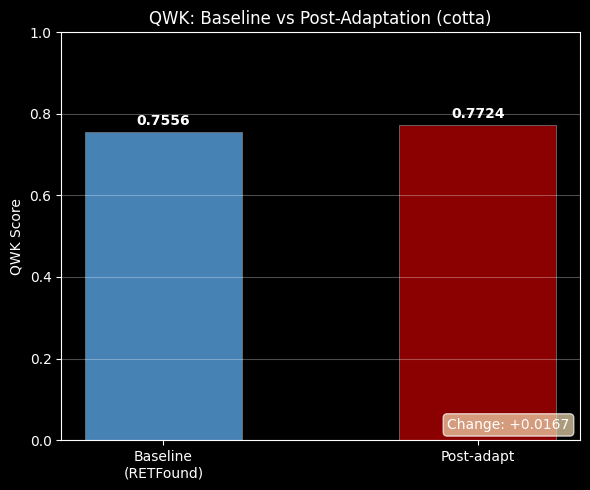

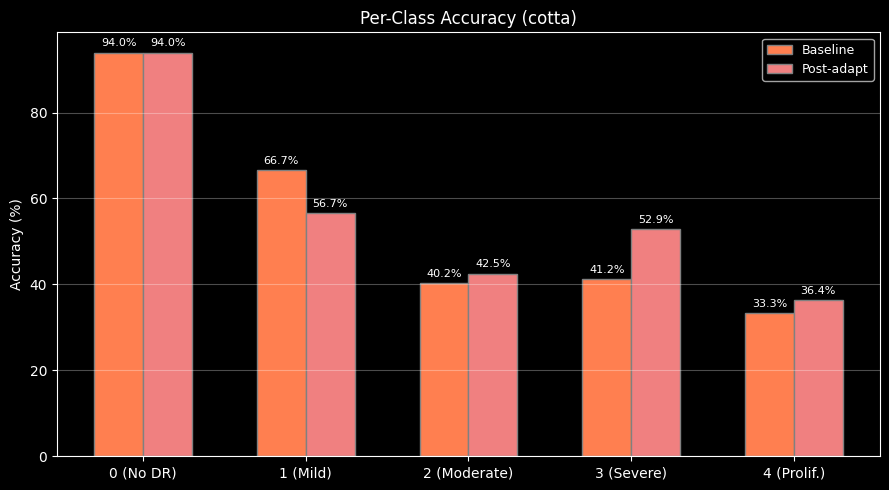

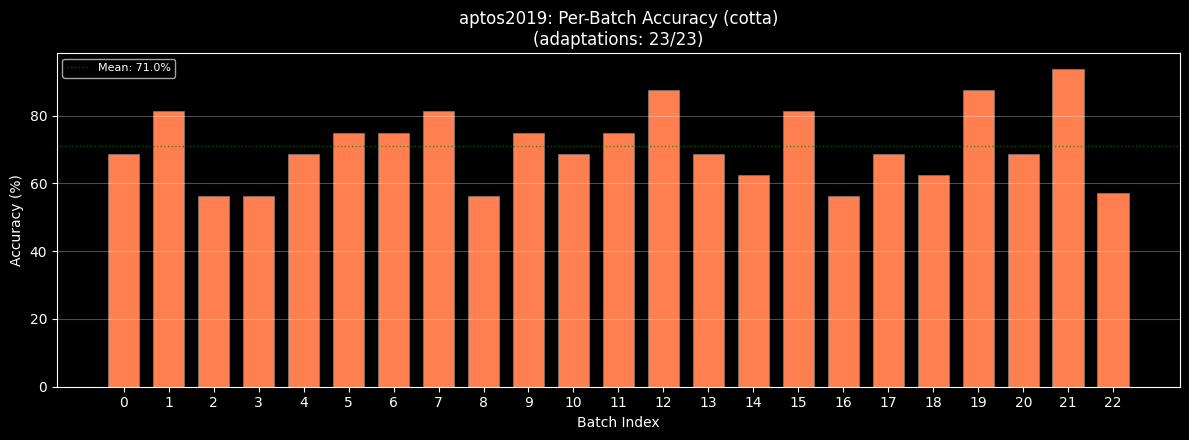

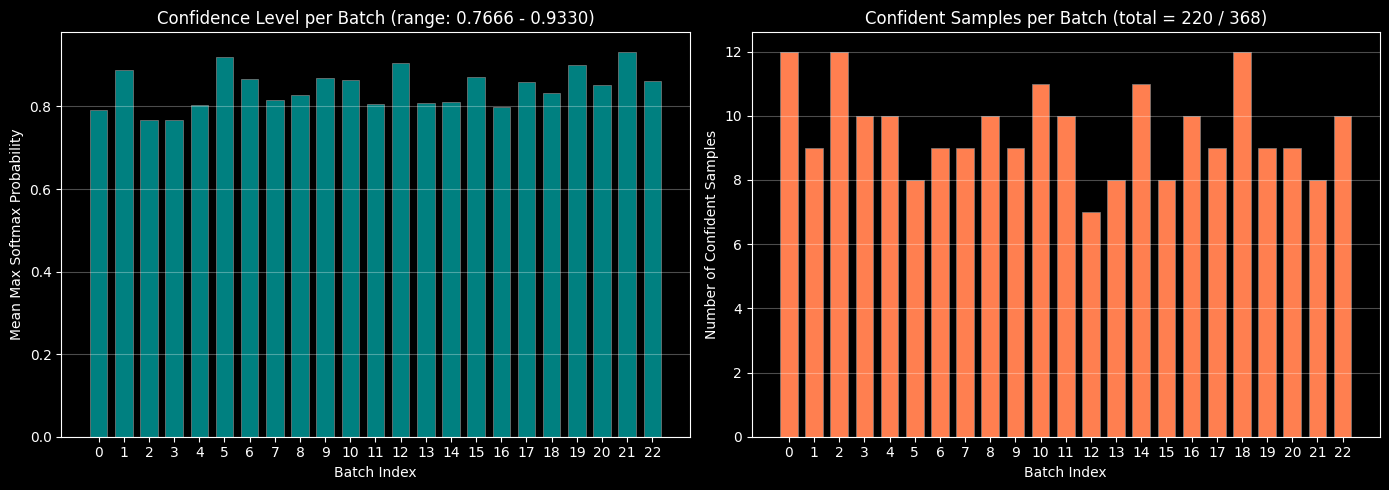

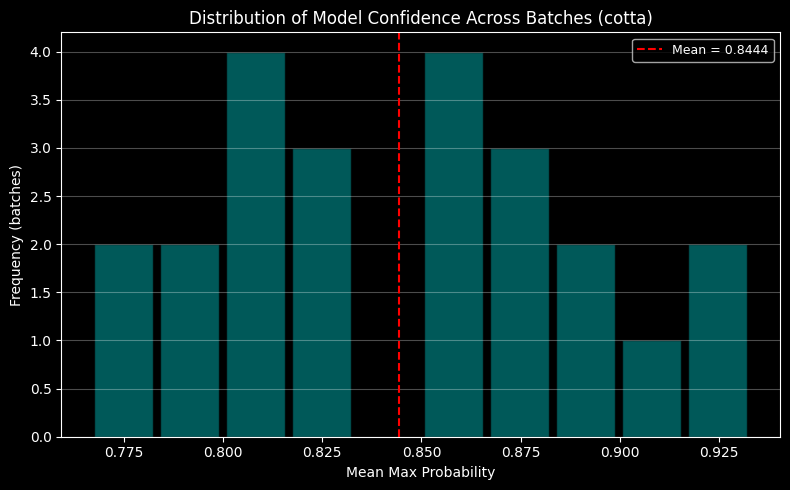

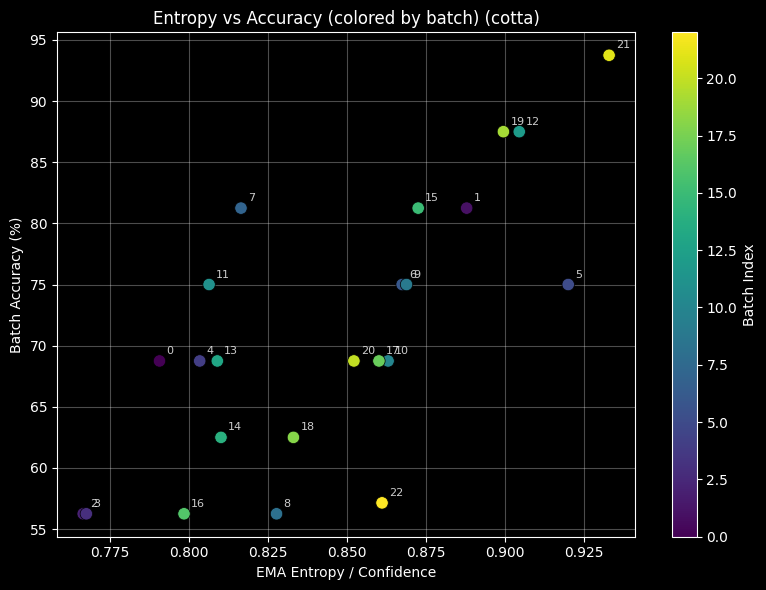

====================== CTTA Results (cotta) =====================
Baseline QWK:       0.7556
Post-adapt QWK:     0.7724
Adaptations:        23/23
Adaptation rate:    100.00%
QWK change:         +0.0167
Mean batch acc:     71.0%


In [7]:
from src.viz import (
    get_domain_data, plot_qwk_bar, plot_per_batch_accuracy,
    plot_adaptation_metrics, plot_confidence_distribution,
    plot_entropy_vs_accuracy, print_summary_table, plot_per_class_accuracy as plot_pca,
)

import json
from pathlib import Path

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

with open(Path(config.output_dir) / 'ctta_results.json') as f:
    results = json.load(f)

dr = results['domain_result']
method = results.get("method", "")

plot_qwk_bar(results, plots_dir, method_name=method)
plot_pca(results, dr, plots_dir, method_name=method)
plot_per_batch_accuracy(dr, None, plots_dir, method_name=method)
plot_adaptation_metrics(dr['adaptation_steps'], plots_dir)
plot_confidence_distribution(dr['adaptation_steps'], plots_dir, method_name=method)
plot_entropy_vs_accuracy(dr['adaptation_steps'], dr['batch_metrics'], plots_dir, method_name=method)
print_summary_table(results, method_name=method)